# Block 2: Predictive Maintenance Pipeline — MUSTERLÖSUNG
## Scikit-Learn Pipelines & MLflow Experiment Tracking

**Szenario**: Sie sind Data Scientist bei einem Maschinenbauer. Ziel: Maschinenausfälle vorhersagen.
**Datensatz**: AI4I 2020 Predictive Maintenance (UCI)

> **Achtung:** Dies ist die Musterlösung. Das Studierenden-Notebook enthält leere Code-Zellen.

---
## 0. Setup & Daten laden

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pathlib
import urllib.request
import warnings
warnings.filterwarnings('ignore')

data_dir = pathlib.Path("data")
data_dir.mkdir(parents=True, exist_ok=True)
csv_path = data_dir / "predictive_maintenance.csv"

if not csv_path.exists():
    url = "https://archive.ics.uci.edu/ml/machine-learning-databases/00601/ai4i2020.csv"
    print(f"Lade Datensatz von UCI...")
    urllib.request.urlretrieve(url, csv_path)
    print(f"Heruntergeladen: {csv_path}")
else:
    print(f"Datensatz vorhanden: {csv_path}")

df = pd.read_csv(csv_path)
print(f"Shape: {df.shape[0]:,} Zeilen x {df.shape[1]} Spalten")
df.head()

Datensatz vorhanden: data/predictive_maintenance.csv
Shape: 10,000 Zeilen x 14 Spalten


,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
0,1,M14860,M,298.1,308.6,1551,42.8,0,0,0,0,0,0,0
1,2,L47181,L,298.2,308.7,1408,46.3,3,0,0,0,0,0,0
2,3,L47182,L,298.1,308.5,1498,49.4,5,0,0,0,0,0,0
3,4,L47183,L,298.2,308.6,1433,39.5,7,0,0,0,0,0,0
4,5,L47184,L,298.2,308.7,1408,40.0,9,0,0,0,0,0,0


---
## Aufgabe A: Business Understanding

### A.1 Kosten-Asymmetrie

**Musterlösung:**

| Fehlerart | Konsequenz | Geschätzte Kosten |
|-----------|-----------|-------------------|
| **False Negative** (Ausfall übersehen) | Ungeplanter Stillstand, Eilreparatur, Folgeschäden, Lieferverzögerungen | 10.000–50.000 € pro Vorfall |
| **False Positive** (unnötige Wartung) | Geplante Inspektion, Personalkosten, kurze Unterbrechung | 500–2.000 € pro Vorfall |

**Kostenverhältnis:** ca. 10:1 bis 25:1 zugunsten der Vermeidung von FN.

### A.2 Ziel-Metrik

**Musterlösung:** Recall ≥ 0.80

**Begründung:** Da ein verpasster Ausfall 10–25× teurer ist als eine unnötige Wartung, priorisieren wir Recall (= möglichst alle echten Ausfälle erkennen). Ein Recall von 0.80 bedeutet, dass wir 80% der Ausfälle rechtzeitig erkennen. Accuracy wäre hier irreführend, da ein "immer kein Ausfall"-Modell bereits ~97% Accuracy hätte.

---
## Aufgabe B: EDA & Datenentscheidungen

### B.1 Explorative Analyse

=== Klassenverteilung ===
Machine failure
0    9661
1     339
Name: count, dtype: int64
Ausfallrate: 3.4%


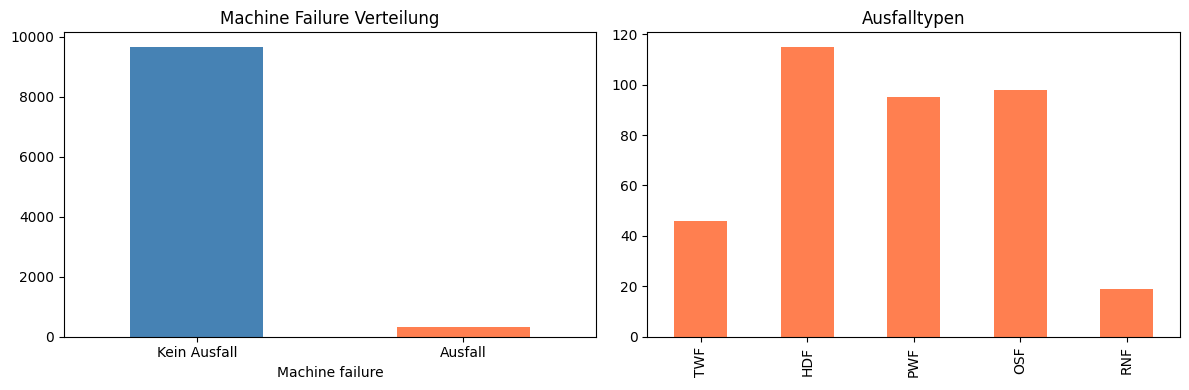

In [2]:
# Klassenverteilung
target_col = 'Machine failure'
failure_types = ['TWF', 'HDF', 'PWF', 'OSF', 'RNF']

print("=== Klassenverteilung ===")
print(df[target_col].value_counts())
print(f"Ausfallrate: {df[target_col].mean()*100:.1f}%")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
df[target_col].value_counts().plot.bar(ax=axes[0], color=['steelblue', 'coral'])
axes[0].set_title('Machine Failure Verteilung')
axes[0].set_xticklabels(['Kein Ausfall', 'Ausfall'], rotation=0)

df[failure_types].sum().plot.bar(ax=axes[1], color='coral')
axes[1].set_title('Ausfalltypen')
plt.tight_layout()
plt.show()

TWF – Tool Wear Failure (Werkzeugverschleiß-Ausfall): Das Werkzeug wird zwischen 200 und 240 Minuten Nutzungsdauer zufällig ersetzt oder fällt aus.
HDF – Heat Dissipation Failure (Wärmeabfuhr-Ausfall): Tritt ein, wenn die Differenz zwischen Prozess- und Lufttemperatur unter 8,6 K liegt und die Rotationsgeschwindigkeit unter 1380 U/min.
PWF – Power Failure (Leistungs-Ausfall): Das Produkt aus Drehmoment und Drehzahl (also die Leistung in Watt) liegt außerhalb des Bereichs von 3500–9000 W.
OSF – Overstrain Failure (Überlastungs-Ausfall): Tritt ein, wenn das Produkt aus Werkzeugverschleiß und Drehmoment bestimmte Schwellen überschreitet (abhängig von der Produktqualität L/M/H).
RNF – Random Failures (Zufällige Ausfälle): Jeder Prozess hat eine Wahrscheinlichkeit von 0,1 %, unabhängig von den Parametern auszufallen.

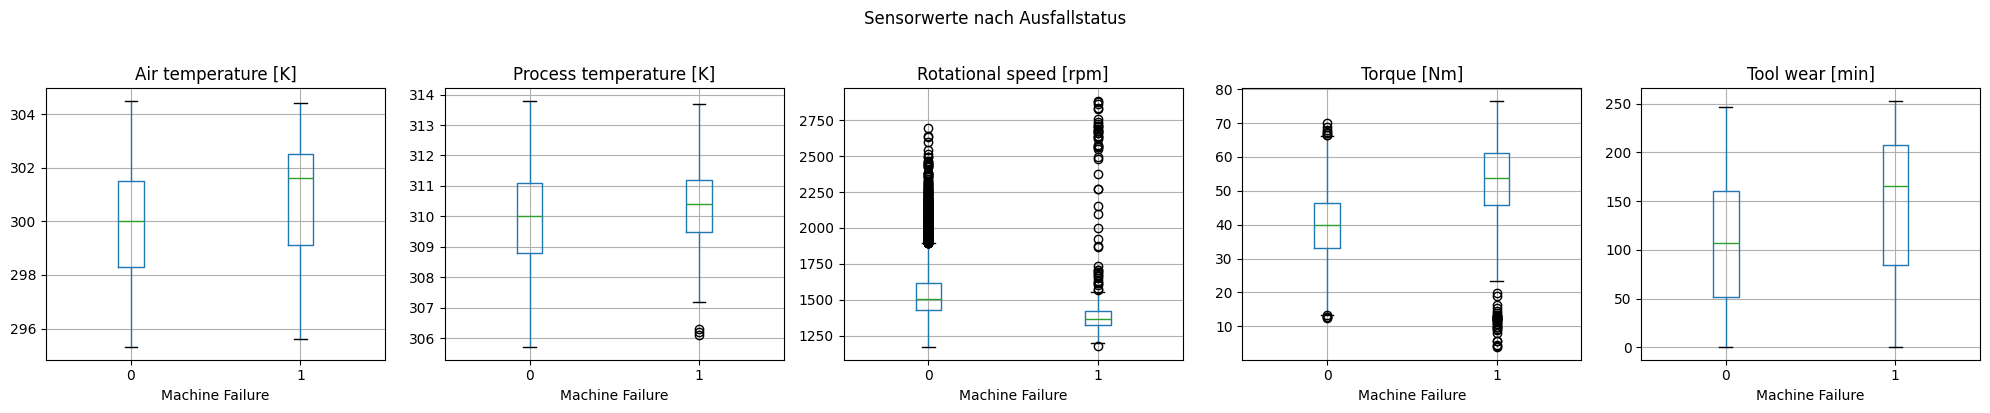

In [3]:
# Sensorwerte nach Ausfall/kein Ausfall
sensor_cols = [c for c in df.select_dtypes(include='number').columns 
               if c not in [target_col, 'UDI'] + failure_types]

fig, axes = plt.subplots(1, len(sensor_cols), figsize=(4*len(sensor_cols), 4))
for ax, col in zip(axes, sensor_cols):
    df.boxplot(column=col, by=target_col, ax=ax)
    ax.set_title(col)
    ax.set_xlabel('Machine Failure')
plt.suptitle('Sensorwerte nach Ausfallstatus', y=1.02)
plt.tight_layout()
plt.show()

In [4]:
# Korrelationen
num_df = df[sensor_cols + [target_col]]
corr = num_df.corr()[target_col].drop(target_col).sort_values(ascending=False)
print("Korrelation mit Machine Failure:")
for feat, val in corr.items():
    print(f"  {feat}: {val:.3f}")

Korrelation mit Machine Failure:
  Torque [Nm]: 0.191
  Tool wear [min]: 0.105
  Air temperature [K]: 0.083
  Process temperature [K]: 0.036
  Rotational speed [rpm]: -0.044


### B.2 Drei Entscheidungen

**Musterlösung:**

**Entscheidung 1 (Ausreißer): Beibehalten.**
Bei Maschinenausfällen sind Extremwerte oft genau die Signale, die wir suchen — überhitzte Temperaturen, ungewöhnliche Drehzahlen. Ausreißer zu entfernen würde die informativen Fälle eliminieren.

**Entscheidung 2 (Product ID): Droppen.**
10.000 einzigartige Werte → kein Informationsgewinn für die Vorhersage. Das Modell würde versuchen, einzelne Werkstücke auswendig zu lernen (Overfitting), statt generalisierbare Muster zu finden.

**Entscheidung 3 (Binär): Binäre Klassifikation.**
Für den Proof-of-Concept ist "Ausfall ja/nein" der sinnvollere erste Schritt. Multiclass mit 5 Ausfalltypen bei nur ~3% Ausfallrate insgesamt ergibt extrem kleine Teilklassen. Erst wenn das binäre Modell funktioniert, kann man erweitern.

---
## Aufgabe C: Scikit-Learn Pipeline bauen

### C.1 Features und Target definieren

In [5]:
from sklearn.model_selection import train_test_split

# Spalten droppen: Identifikatoren + Ausfalltypen (Target Leakage!)
drop_cols = ['UDI', 'Product ID'] + [c for c in failure_types if c in df.columns]
X = df.drop(columns=drop_cols + [target_col])
y = df[target_col]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(f"Train: {X_train.shape}, Test: {X_test.shape}")
print(f"Ausfallrate Train: {y_train.mean():.3f}, Test: {y_test.mean():.3f}")
print(f"Features: {list(X.columns)}")

Train: (8000, 6), Test: (2000, 6)
Ausfallrate Train: 0.034, Test: 0.034
Features: ['Type', 'Air temperature [K]', 'Process temperature [K]', 'Rotational speed [rpm]', 'Torque [Nm]', 'Tool wear [min]']


### C.2 ColumnTransformer + Pipeline

In [6]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer

num_cols = X_train.select_dtypes(include=['int64', 'float64']).columns.tolist()
cat_cols = X_train.select_dtypes(include=['object', 'category']).columns.tolist()

print(f"Numerische Features ({len(num_cols)}): {num_cols}")
print(f"Kategorische Features ({len(cat_cols)}): {cat_cols}")

preprocessor = ColumnTransformer([
    ("num", Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
    ]), num_cols),
    ("cat", Pipeline([
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("encoder", OneHotEncoder(handle_unknown="ignore", sparse_output=False)),
    ]), cat_cols),
])

Numerische Features (5): ['Air temperature [K]', 'Process temperature [K]', 'Rotational speed [rpm]', 'Torque [Nm]', 'Tool wear [min]']
Kategorische Features (1): ['Type']


### C.3 Drei Modelle vergleichen

In [7]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.model_selection import cross_val_score, StratifiedKFold

models = {
    "LogReg": LogisticRegression(max_iter=1000, random_state=42),
    "RandomForest": RandomForestClassifier(n_estimators=100, random_state=42),
    "GradientBoosting": GradientBoostingClassifier(n_estimators=100, random_state=42),
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
scoring = "recall"  # Wegen Kosten-Asymmetrie: Recall priorisieren

results = {}
for name, model in models.items():
    pipe = Pipeline([("preprocessor", preprocessor), ("model", model)])
    scores = cross_val_score(pipe, X_train, y_train, cv=cv, scoring=scoring)
    results[name] = {"mean": scores.mean(), "std": scores.std()}
    print(f"{name}: Recall = {scores.mean():.4f} (+/- {scores.std():.4f})")

LogReg: Recall = 0.1993 (+/- 0.0276)
RandomForest: Recall = 0.4577 (+/- 0.0514)
GradientBoosting: Recall = 0.6017 (+/- 0.0610)


---
## Aufgabe D: MLflow Tracking

### D.1 Setup

In [8]:
import mlflow
import mlflow.sklearn
from sklearn.metrics import (
    accuracy_score, f1_score, precision_score, recall_score,
    confusion_matrix, ConfusionMatrixDisplay
)

# SQLite-Backend (nötig für den Overview-Tab der MLflow-UI)
# Artefakte (Modelle, Plots) liegen weiter im mlruns/-Ordner
import os
db_path = os.path.join(os.getcwd(), "mlflow.db")
artifacts_path = os.path.join(os.getcwd(), "mlruns")
mlflow.set_tracking_uri(f"sqlite:///{db_path}")
mlflow.set_experiment("Block2-Predictive-Maintenance")
print(f"MLflow konfiguriert. Tracking DB: {db_path}")
print(f"Artifacts:                       {artifacts_path}")
print(f"UI starten mit:")
print(f"  mlflow ui --backend-store-uri sqlite:///{db_path} --default-artifact-root file://{artifacts_path}")

MLflow konfiguriert. Tracking DB: /Users/sschacht/Downloads/notebooks/mlflow.db
Artifacts:                       /Users/sschacht/Downloads/notebooks/mlruns
UI starten mit:
  mlflow ui --backend-store-uri sqlite:////Users/sschacht/Downloads/notebooks/mlflow.db --default-artifact-root file:///Users/sschacht/Downloads/notebooks/mlruns


### D.2 Alle Modelle loggen

In [9]:
for name, model in models.items():
    with mlflow.start_run(run_name=name):
        # Pipeline bauen und trainieren
        pipe = Pipeline([("preprocessor", preprocessor), ("model", model)])
        pipe.fit(X_train, y_train)
        y_pred = pipe.predict(X_test)

        # Metriken berechnen
        acc = accuracy_score(y_test, y_pred)
        f1 = f1_score(y_test, y_pred)
        prec = precision_score(y_test, y_pred)
        rec = recall_score(y_test, y_pred)

        # In MLflow loggen
        mlflow.log_param("model_type", name)
        mlflow.log_metric("accuracy", acc)
        mlflow.log_metric("f1", f1)
        mlflow.log_metric("precision", prec)
        mlflow.log_metric("recall", rec)

        # Confusion Matrix als Artefakt
        fig, ax = plt.subplots(figsize=(5, 4))
        ConfusionMatrixDisplay.from_predictions(y_test, y_pred, ax=ax)
        ax.set_title(f"{name} — Confusion Matrix")
        cm_path = f"cm_{name}.png"
        fig.savefig(cm_path, bbox_inches='tight')
        mlflow.log_artifact(cm_path)
        plt.close()

        # Modell speichern (name= statt positional, input_example für Signatur)
        mlflow.sklearn.log_model(pipe, name="model", input_example=X_test.iloc[:1])

        print(f"{name}: acc={acc:.3f}, f1={f1:.3f}, prec={prec:.3f}, rec={rec:.3f}")

2026/04/17 14:48:32 INFO mlflow.utils.uv_utils: Detected uv project: found uv.lock and pyproject.toml in /Users/sschacht/Downloads/notebooks
2026/04/17 14:48:32 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html
2026/04/17 14:48:32 INFO mlflow.utils.uv_utils: Detected uv project: found uv.lock and pyproject.toml in /Users/sschacht/Downloads/notebooks
2026/04/17 14:48:32 INFO mlflow.utils.environment: Detected uv project at /Users/sschacht/Downloads/notebooks. Attempting to export requirements via 'uv export'.
2026/04/17 14:48:32 INFO mlflow.utils.uv_utils: Exported 175 dependencies via uv
2026/04/17 14:48:32 INFO mlflow.utils.environment: Successfully exported 1

LogReg: acc=0.968, f1=0.177, prec=0.636, rec=0.103


2026/04/17 14:48:33 INFO mlflow.utils.uv_utils: Detected uv project: found uv.lock and pyproject.toml in /Users/sschacht/Downloads/notebooks
2026/04/17 14:48:33 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html
2026/04/17 14:48:33 INFO mlflow.utils.uv_utils: Detected uv project: found uv.lock and pyproject.toml in /Users/sschacht/Downloads/notebooks
2026/04/17 14:48:33 INFO mlflow.utils.environment: Detected uv project at /Users/sschacht/Downloads/notebooks. Attempting to export requirements via 'uv export'.
2026/04/17 14:48:33 INFO mlflow.utils.uv_utils: Exported 175 dependencies via uv
2026/04/17 14:48:33 INFO mlflow.utils.environment: Successfully exported 1

RandomForest: acc=0.982, f1=0.654, prec=0.897, rec=0.515


2026/04/17 14:48:34 INFO mlflow.utils.uv_utils: Detected uv project: found uv.lock and pyproject.toml in /Users/sschacht/Downloads/notebooks
2026/04/17 14:48:34 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html
2026/04/17 14:48:34 INFO mlflow.utils.uv_utils: Detected uv project: found uv.lock and pyproject.toml in /Users/sschacht/Downloads/notebooks
2026/04/17 14:48:34 INFO mlflow.utils.environment: Detected uv project at /Users/sschacht/Downloads/notebooks. Attempting to export requirements via 'uv export'.
2026/04/17 14:48:34 INFO mlflow.utils.uv_utils: Exported 175 dependencies via uv
2026/04/17 14:48:34 INFO mlflow.utils.environment: Successfully exported 1

GradientBoosting: acc=0.986, f1=0.756, prec=0.882, rec=0.662


### D.2b Alternative mit `mlflow.autolog()`

Alternativ kann man `mlflow.sklearn.autolog()` nutzen. Damit werden Params, Training-Metriken, das Modell (inkl. Signatur & Input-Example) automatisch geloggt. Test-Metriken müssen weiter explizit geloggt werden, weil autolog nur die Trainings-Seite kennt.

In [10]:
# Autolog aktiviert: Params + Train-Metriken + Modell werden automatisch geloggt
mlflow.sklearn.autolog(
    log_input_examples=True,
    log_model_signatures=True,
    log_models=True,
)

for name, model in models.items():
    with mlflow.start_run(run_name=f"{name}-autolog"):
        pipe = Pipeline([("preprocessor", preprocessor), ("model", model)])
        pipe.fit(X_train, y_train)

        # Test-Metriken zusätzlich loggen (autolog erfasst nur Training)
        y_pred = pipe.predict(X_test)
        mlflow.log_metrics({
            "test_accuracy":  accuracy_score(y_test, y_pred),
            "test_f1":        f1_score(y_test, y_pred),
            "test_precision": precision_score(y_test, y_pred),
            "test_recall":    recall_score(y_test, y_pred),
        })
        print(f"{name}-autolog: test_recall={recall_score(y_test, y_pred):.3f}")

# Autolog wieder ausschalten, damit nachfolgende Zellen nichts Ungewolltes loggen
mlflow.sklearn.autolog(disable=True)

2026/04/17 14:49:19 INFO mlflow.utils.uv_utils: Detected uv project: found uv.lock and pyproject.toml in /Users/sschacht/Downloads/notebooks
2026/04/17 14:49:19 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html
2026/04/17 14:49:19 INFO mlflow.utils.uv_utils: Detected uv project: found uv.lock and pyproject.toml in /Users/sschacht/Downloads/notebooks
2026/04/17 14:49:19 INFO mlflow.utils.environment: Detected uv project at /Users/sschacht/Downloads/notebooks. Attempting to export requirements via 'uv export'.
2026/04/17 14:49:19 INFO mlflow.utils.uv_utils: Exported 175 dependencies via uv
2026/04/17 14:49:19 INFO mlflow.utils.environment: Successfully exported 1

LogReg-autolog: test_recall=0.103


2026/04/17 14:49:20 INFO mlflow.utils.uv_utils: Detected uv project: found uv.lock and pyproject.toml in /Users/sschacht/Downloads/notebooks
2026/04/17 14:49:20 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html
2026/04/17 14:49:20 INFO mlflow.utils.uv_utils: Detected uv project: found uv.lock and pyproject.toml in /Users/sschacht/Downloads/notebooks
2026/04/17 14:49:20 INFO mlflow.utils.environment: Detected uv project at /Users/sschacht/Downloads/notebooks. Attempting to export requirements via 'uv export'.
2026/04/17 14:49:20 INFO mlflow.utils.uv_utils: Exported 175 dependencies via uv
2026/04/17 14:49:20 INFO mlflow.utils.environment: Successfully exported 1

RandomForest-autolog: test_recall=0.515


2026/04/17 14:49:21 INFO mlflow.utils.uv_utils: Detected uv project: found uv.lock and pyproject.toml in /Users/sschacht/Downloads/notebooks
2026/04/17 14:49:21 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html
2026/04/17 14:49:21 INFO mlflow.utils.uv_utils: Detected uv project: found uv.lock and pyproject.toml in /Users/sschacht/Downloads/notebooks
2026/04/17 14:49:21 INFO mlflow.utils.environment: Detected uv project at /Users/sschacht/Downloads/notebooks. Attempting to export requirements via 'uv export'.
2026/04/17 14:49:21 INFO mlflow.utils.uv_utils: Exported 175 dependencies via uv
2026/04/17 14:49:21 INFO mlflow.utils.environment: Successfully exported 1

GradientBoosting-autolog: test_recall=0.662


### D.3 MLflow UI interpretieren

**Musterlösung:** GradientBoosting zeigt typischerweise den besten Recall bei akzeptabler Precision. Die Wahl hängt von der konkreten Kosten-Asymmetrie ab — bei 10:1 Kostenverhältnis (FN vs. FP) ist das Modell mit dem höchsten Recall zu bevorzugen, sofern die Precision nicht unter ein akzeptables Minimum fällt.

---
## Aufgabe E: Reflexionsfragen

**Frage 1: Recall 0.85 — deployen?**

**Musterlösung:** Ja, aber als Assistenzsystem, nicht als vollautonome Entscheidung. 85% der Ausfälle rechtzeitig zu erkennen ist deutlich besser als 0% (Status quo ohne Modell). Die verbleibenden 15% FN erfordern weiterhin menschliche Expertise und regelmäßige manuelle Inspektionen. Das Modell sollte Warnungen ausgeben, die ein Mensch prüft — nicht eigenständig Maschinen abschalten.

**Frage 2: Scaler ohne Pipeline — was passiert?**

**Musterlösung:** Data Leakage. Wenn der Scaler auf dem gesamten Datensatz (inkl. Testdaten) gefittet wird, fließen Informationen aus dem Testset in die Transformation der Trainingsdaten ein (Mittelwert, Standardabweichung). Das Modell "sieht" indirekt Testdaten und erscheint in der Evaluation besser, als es in der Praxis wäre. Die Pipeline stellt sicher, dass der Scaler nur auf Trainingsdaten gefittet wird.

**Frage 3: Welche CRISP-DM Phase?**

**Musterlösung:** Wir befinden uns in der **Evaluation**-Phase. Es fehlt noch **Deployment**: Monitoring im Produktivbetrieb, A/B-Tests gegen den Status quo, Integration in das Leitsystem der Fabrik, Festlegung von Schwellenwerten für Alarme, und ein Plan für Modell-Updates wenn sich die Maschinendaten über die Zeit verändern (Concept Drift).

---
## Bonus: Baseline-Vergleich

Wie gut ist ein naives Modell, das immer "kein Ausfall" vorhersagt?

In [11]:
# Naive Baseline: immer "kein Ausfall" vorhersagen
naive_acc = 1 - y_test.mean()
print(f"Naive Baseline (immer 0):")
print(f"  Accuracy: {naive_acc:.3f}  (klingt gut!)")
print(f"  Recall:   0.000  (erkennt keinen einzigen Ausfall)")
print(f"  F1:       0.000")
print(f"")
print(f"→ Accuracy allein ist bei diesem Datensatz wertlos.")
print(f"  Jedes Modell mit Recall > 0 ist besser als die Baseline.")

Naive Baseline (immer 0):
  Accuracy: 0.966  (klingt gut!)
  Recall:   0.000  (erkennt keinen einzigen Ausfall)
  F1:       0.000

→ Accuracy allein ist bei diesem Datensatz wertlos.
  Jedes Modell mit Recall > 0 ist besser als die Baseline.
